Setup env

In [1]:
pip install nltk gensim scikit-learn numpy seaborn

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip3.10 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install --user --upgrade scipy


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: pip3.10 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
# nltk.download('resource_name')

[nltk_data] Downloading package punkt to /home/hlakhal-/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/hlakhal-/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/hlakhal-/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/hlakhal-/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

Data Exploration

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer


In [5]:
def load_tweet_file(path):
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        content = f.read()
    if '\n' in content.strip() and content.count('\n') > 5:
        tweets = [line.strip() for line in content.split('\n') if line.strip()]
    else:
        tweets = [t.strip() for t in content.split(',') if t.strip()]
    return pd.DataFrame({'tweets': tweets})

neg = load_tweet_file('../data/processedNegative.csv')
pos = load_tweet_file('../data/processedPositive.csv')
neu = load_tweet_file('../data/processedNeutral.csv')

print(neg.shape, pos.shape, neu.shape)


(1116, 1) (1183, 1) (1566, 1)


(3865, 2)
label
Neutral     1566
Positive    1183
Negative    1116
Name: count, dtype: int64


<Axes: xlabel='label'>

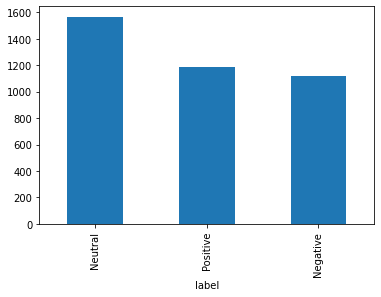

In [6]:
neg['label'] = 'Negative'
pos['label'] = 'Positive'
neu['label'] = 'Neutral'

df = pd.concat([neg, pos, neu], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
print(df['label'].value_counts())

df.head()

df['label'].value_counts().plot(kind='bar')

In [7]:
df['char_length'] = df['tweets'].apply(len)

df['word_count'] = df['tweets'].apply(lambda x: len(x.split()))

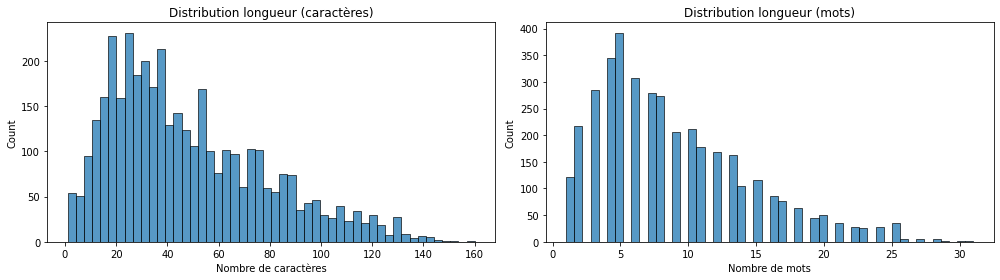

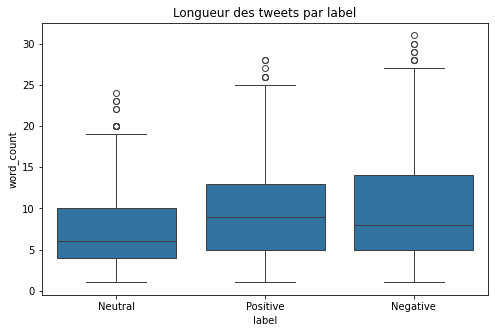

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['char_length'], bins=50, ax=axes[0])
axes[0].set_title('Distribution longueur (caractères)')
axes[0].set_xlabel('Nombre de caractères')

sns.histplot(df['word_count'], bins=50, ax=axes[1])
axes[1].set_title('Distribution longueur (mots)')
axes[1].set_xlabel('Nombre de mots')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='label', y='word_count')
plt.title('Longueur des tweets par label')
plt.show()

In [9]:
n_dup = df.duplicated(subset='tweets').sum()

duplicated_tweets = df[df.duplicated(subset='tweets', keep=False)].sort_values('tweets')
duplicated_tweets.head(10)

duplicates_check = df[df.duplicated(subset='tweets', keep=False)]
label_consistency = duplicates_check.groupby('tweets')['label'].nunique()
inconsistent = label_consistency[label_consistency > 1]

print(len(inconsistent))

1


In [10]:
df_clean = df.drop_duplicates(subset='tweets', keep='first')
df_clean['tweets'] = df_clean['tweets'].fillna('')
df_clean = df_clean.dropna(subset=['tweets'])

/tmp/ipykernel_2946518/663372415.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['tweets'] = df_clean['tweets'].fillna('')


In [ ]:
print(f"{len(df_clean)}----{len(df)}")

df_clean


In [22]:
def preprocess_text(text):
    text = re.sub(r'<.*?> | www\.[a-z]?\.?(com)+ |[a-z]+\.(com) | @mention ', '', text)
    
    text = text.lower()

    tokens = word_tokenize(text=text)

    stop_words = set(stopwords.words('english'))
    token = [word for word in tokens if word not in stop_words]

    stemmer = PorterStemmer()
    tokens = [stemmer.stem(word) for word in tokens]

    clean_text  = ' '.join(tokens)

    return clean_text

df_clean['tweets'] = df_clean['tweets'].apply(preprocess_text)

df_clean['char_length'] = df_clean['tweets'].apply(len)

df_clean['word_count'] = df_clean['tweets'].apply(lambda x: len(x.split()))

df_clean.head(10)


,tweets,label,char_length,word_count
0,pari,Neutral,4,1
1,thank for connect we are passion about - hope ...,Positive,70,14
2,transfer in 1st major shuffl by,Neutral,31,6
3,share the love : thank for be top new follow t...,Positive,59,13
4,just now i saw . but you did not repli unhappi,Negative,46,11
5,suprem court ask poll panel if secur of need t...,Neutral,55,12
6,thank for be top engag commun member thi week ...,Positive,60,12
7,sorri unhappi i just need sex for the time be,Negative,45,10
8,i hope thi littl beaand is andot overworkiandg...,Negative,95,16
9,say,Neutral,3,1
